In [27]:
import mysql.connector
import pandas as pd

# Connect to MySQL
connection = mysql.connector.connect(
    host="localhost",
    port=3306,
    user="root",
    password="Rajesh@6360",
    database="SaaS_Subscription_Metrics"
)

# Check connection
print("MySQL connected:", connection.is_connected())

# Create cursor
cursor = connection.cursor()

# Show tables
cursor.execute("SHOW TABLES;")

print("\nTables in database:")

for table in cursor:
    print(table)

# Load customers
customers = pd.read_sql(
    "SELECT * FROM customers",
    connection
)

print("\nCustomers shape:", customers.shape)

customers.head()

MySQL connected: True

Tables in database:
('customers',)
('metrics',)
('payment',)
('subscription',)
('tickets',)

Customers shape: (12000, 6)


C:\Users\rajes\AppData\Local\Temp\ipykernel_80748\2409038011.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql(


,customer_id,signup_date,country,industry,company_size,acquisition_channel
0,CUST00001,2024-03-06 00:00:00,USA,Retail,Medium,Partner
1,CUST00002,2025-07-18 00:00:00,India,Technology,Small,Organic Search
2,CUST00003,2025-04-22 00:00:00,UK,Healthcare,Small,Paid Ads
3,CUST00004,2024-11-16 00:00:00,India,Education,Small,Organic Search
4,CUST00005,2024-11-12 00:00:00,India,Retail,Small,Paid Ads


In [28]:
pd.read_sql("SHOW TABLES;", connection)

C:\Users\rajes\AppData\Local\Temp\ipykernel_80748\2351832901.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql("SHOW TABLES;", connection)


,Tables_in_saas_subscription_metrics
0,customers
1,metrics
2,payment
3,subscription
4,tickets


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [30]:
tables = pd.read_sql(
    "SHOW TABLES;",
    connection
)

tables

C:\Users\rajes\AppData\Local\Temp\ipykernel_80748\1493321318.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables = pd.read_sql(


,Tables_in_saas_subscription_metrics
0,customers
1,metrics
2,payment
3,subscription
4,tickets


In [31]:
subscription = pd.read_sql(
    "SELECT * FROM subscription;",
    connection
)

payment = pd.read_sql(
    "SELECT * FROM payment;",
    connection
)

metrics = pd.read_sql(
    "SELECT * FROM metrics;",
    connection
)

tickets = pd.read_sql(
    "SELECT * FROM tickets;",
    connection
)

C:\Users\rajes\AppData\Local\Temp\ipykernel_80748\397500717.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  subscription = pd.read_sql(
C:\Users\rajes\AppData\Local\Temp\ipykernel_80748\397500717.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  payment = pd.read_sql(
C:\Users\rajes\AppData\Local\Temp\ipykernel_80748\397500717.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  metrics = pd.read_sql(
C:\Users\rajes\AppData\Local\Temp\ipykernel_80748\397500717.py:16: UserWarning: pandas only supports SQLAlchemy connec

In [32]:
print("Customers:", customers.shape)
print("Subscription:", subscription.shape)
print("Payment:", payment.shape)
print("metrics:", metrics.shape)
print("tickets:", tickets.shape)

Customers: (12000, 6)
Subscription: (12000, 11)
Payment: (150773, 7)
metrics: (150773, 8)
tickets: (26326, 8)


In [33]:
customers.head()

,customer_id,signup_date,country,industry,company_size,acquisition_channel
0,CUST00001,2024-03-06 00:00:00,USA,Retail,Medium,Partner
1,CUST00002,2025-07-18 00:00:00,India,Technology,Small,Organic Search
2,CUST00003,2025-04-22 00:00:00,UK,Healthcare,Small,Paid Ads
3,CUST00004,2024-11-16 00:00:00,India,Education,Small,Organic Search
4,CUST00005,2024-11-12 00:00:00,India,Retail,Small,Paid Ads


In [34]:
subscription.head()

,subscription_id,customer_id,plan_name,billing_cycle,start_date,end_date,monthly_price,status,cancellation_reason,upgrade_flag,downgrade_flag
0,SUB0000001,CUST00001,Pro,Annual,2024-03-06 00:00:00,,149,Active,,0,0
1,SUB0000002,CUST00002,Pro,Annual,2025-07-18 00:00:00,,149,Active,,0,0
2,SUB0000003,CUST00003,Pro,Annual,2025-04-22 00:00:00,,149,Active,,1,0
3,SUB0000004,CUST00004,Pro,Annual,2024-11-16 00:00:00,,149,Active,,0,0
4,SUB0000005,CUST00005,Enterprise,Monthly,2024-11-12 00:00:00,,499,Active,,1,0


In [35]:
payment.head()

,payment_Id,customer_id,subscription_id,payment_date,amount,payment_status,payment_method
0,PAY00000001,CUST00001,SUB0000001,2024-03-01 00:00:00,149,Paid,Card
1,PAY00000002,CUST00001,SUB0000001,2024-04-01 00:00:00,149,Paid,Card
2,PAY00000003,CUST00001,SUB0000001,2024-05-01 00:00:00,149,Paid,UPI
3,PAY00000004,CUST00001,SUB0000001,2024-06-01 00:00:00,149,Paid,Bank Transfer
4,PAY00000005,CUST00001,SUB0000001,2024-07-01 00:00:00,149,Paid,Bank Transfer


In [36]:
metrics.head()

,customer_id,usage_date,login_count,active_users,sessions,usage_minutes,feature_usage,api_calls
0,CUST00001,2024-03-01 00:00:00,20,9,46,1196,9,920
1,CUST00001,2024-04-01 00:00:00,38,19,95,1140,15,9310
2,CUST00001,2024-05-01 00:00:00,20,9,54,864,17,4482
3,CUST00001,2024-06-01 00:00:00,16,6,38,1216,12,4180
4,CUST00001,2024-07-01 00:00:00,37,15,92,3036,32,2208


In [37]:
tickets.head()

,ticket_Id,customer_id,ticket_date,issue_type,priority,resolution_time_hours,satisfaction_score,ticket_status
0,TKT0000001,CUST00001,2024-06-02 00:00:00,Account,Low,17.5,5,Closed
1,TKT0000002,CUST00001,2024-01-19 00:00:00,Product,Low,25.8,2,Closed
2,TKT0000003,CUST00001,2024-06-14 00:00:00,Account,Medium,33.8,4,Closed
3,TKT0000004,CUST00002,2024-11-19 00:00:00,Billing,Low,1.2,4,Closed
4,TKT0000005,CUST00002,2025-05-14 00:00:00,Account,Medium,12.5,2,Closed


DATA VALIDATION

In [38]:
print("CUSTOMERS")
print(customers.columns.tolist())

CUSTOMERS
['customer_id', 'signup_date', 'country', 'industry', 'company_size', 'acquisition_channel']


In [39]:
subscriptions = pd.read_sql(
    "SELECT * FROM subscription;",
    connection
)


C:\Users\rajes\AppData\Local\Temp\ipykernel_80748\2068339710.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  subscriptions = pd.read_sql(


In [40]:
print("\nSUBSCRIPTION")
print(subscription.columns.tolist())


SUBSCRIPTION
['subscription_id', 'customer_id', 'plan_name', 'billing_cycle', 'start_date', 'end_date', 'monthly_price', 'status', 'cancellation_reason', 'upgrade_flag', 'downgrade_flag']


In [41]:
print("\nPAYMENT")
print(payment.columns.tolist())


PAYMENT
['payment_Id', 'customer_id', 'subscription_id', 'payment_date', 'amount', 'payment_status', 'payment_method']


In [42]:
print("\nMETRICS")
print(metrics.columns.tolist())


METRICS
['customer_id', 'usage_date', 'login_count', 'active_users', 'sessions', 'usage_minutes', 'feature_usage', 'api_calls']


In [43]:
print("\nTICKETS")
print(tickets.columns.tolist())


TICKETS
['ticket_Id', 'customer_id', 'ticket_date', 'issue_type', 'priority', 'resolution_time_hours', 'satisfaction_score', 'ticket_status']


In [44]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          12000 non-null  object
 1   signup_date          12000 non-null  object
 2   country              12000 non-null  object
 3   industry             12000 non-null  object
 4   company_size         12000 non-null  object
 5   acquisition_channel  12000 non-null  object
dtypes: object(6)
memory usage: 562.6+ KB


In [45]:
subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   subscription_id      12000 non-null  object
 1   customer_id          12000 non-null  object
 2   plan_name            12000 non-null  object
 3   billing_cycle        12000 non-null  object
 4   start_date           12000 non-null  object
 5   end_date             12000 non-null  object
 6   monthly_price        12000 non-null  int64 
 7   status               12000 non-null  object
 8   cancellation_reason  12000 non-null  object
 9   upgrade_flag         12000 non-null  int64 
 10  downgrade_flag       12000 non-null  int64 
dtypes: int64(3), object(8)
memory usage: 1.0+ MB


In [46]:
payment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150773 entries, 0 to 150772
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   payment_Id       150773 non-null  object
 1   customer_id      150773 non-null  object
 2   subscription_id  150773 non-null  object
 3   payment_date     150773 non-null  object
 4   amount           150773 non-null  int64 
 5   payment_status   150773 non-null  object
 6   payment_method   150773 non-null  object
dtypes: int64(1), object(6)
memory usage: 8.1+ MB


In [47]:
metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150773 entries, 0 to 150772
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   customer_id    150773 non-null  object
 1   usage_date     150773 non-null  object
 2   login_count    150773 non-null  int64 
 3   active_users   150773 non-null  int64 
 4   sessions       150773 non-null  int64 
 5   usage_minutes  150773 non-null  int64 
 6   feature_usage  150773 non-null  int64 
 7   api_calls      150773 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.2+ MB


In [48]:
tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26326 entries, 0 to 26325
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_Id              26326 non-null  object 
 1   customer_id            26326 non-null  object 
 2   ticket_date            26326 non-null  object 
 3   issue_type             26326 non-null  object 
 4   priority               26326 non-null  object 
 5   resolution_time_hours  26326 non-null  float64
 6   satisfaction_score     26326 non-null  int64  
 7   ticket_status          26326 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 1.6+ MB


Converting dates

In [49]:
customers["signup_date"] = pd.to_datetime(
    customers["signup_date"],
    errors="coerce"
)

In [50]:
subscription["start_date"] = pd.to_datetime(
    subscription["start_date"],
    errors="coerce"
)

In [51]:
subscription["end_date"] = pd.to_datetime(
    subscription["end_date"],
    errors="coerce"
)

In [52]:
payment["payment_date"] = pd.to_datetime(
    payment["payment_date"],
    errors="coerce"
)

In [53]:
tickets["ticket_date"] = pd.to_datetime(
    tickets["ticket_date"],
    errors="coerce"
)

In [54]:
print("customers")
print(customers.isnull().sum())

customers
customer_id            0
signup_date            0
country                0
industry               0
company_size           0
acquisition_channel    0
dtype: int64


In [55]:
print("subscription")
print(subscription.isnull().sum())

subscription
subscription_id            0
customer_id                0
plan_name                  0
billing_cycle              0
start_date                 0
end_date               11747
monthly_price              0
status                     0
cancellation_reason        0
upgrade_flag               0
downgrade_flag             0
dtype: int64


In [56]:
print("payment")
print(payment.isnull().sum())

payment
payment_Id         0
customer_id        0
subscription_id    0
payment_date       0
amount             0
payment_status     0
payment_method     0
dtype: int64


In [57]:
print("metrics")
print(metrics.isnull().sum())

metrics
customer_id      0
usage_date       0
login_count      0
active_users     0
sessions         0
usage_minutes    0
feature_usage    0
api_calls        0
dtype: int64


In [58]:
print("tickets")
print(tickets.isnull().sum())

tickets
ticket_Id                0
customer_id              0
ticket_date              0
issue_type               0
priority                 0
resolution_time_hours    0
satisfaction_score       0
ticket_status            0
dtype: int64


In [59]:
print("Customer duplicates:",
      customers["customer_id"].duplicated().sum())

Customer duplicates: 0


In [60]:
print("subscription duplicates:",
      subscription["subscription_id"].duplicated().sum())

subscription duplicates: 0


In [61]:
print("Payment duplicates:",
      payment["payment_Id"].duplicated().sum())

Payment duplicates: 0


In [62]:
print("metrics duplicates:",
      metrics["customer_id"].duplicated().sum())

metrics duplicates: 138773


In [63]:
print("tickets duplicates:",
      tickets["ticket_Id"].duplicated().sum())

tickets duplicates: 0


Check The invalid numeric values

In [64]:
print("Negative subscription prices:",
      (subscription["monthly_price"] < 0).sum())


Negative subscription prices: 0


In [65]:
print("Negative login counts:",
      (metrics["login_count"] < 0).sum())

Negative login counts: 0


In [66]:
print("Nagative usage minutes:",
      (metrics["usage_minutes"] < 0).sum())

Nagative usage minutes: 0


In [67]:
print("invalied satisfaction score :",
      ((tickets["satisfaction_score"] < 1) |
       (tickets["satisfaction_score"] > 5)).sum())

invalied satisfaction score : 0


Check categorical values

In [68]:
print(subscription["plan_name"].value_counts())

plan_name
Basic         5055
Pro           4682
Enterprise    2263
Name: count, dtype: int64


In [69]:
print(subscription["status"].value_counts())

status
Active     11747
Churned      253
Name: count, dtype: int64


In [70]:
print(subscription["billing_cycle"].value_counts())

billing_cycle
Monthly    8671
Annual     3329
Name: count, dtype: int64


In [71]:
print(customers["acquisition_channel"].value_counts())

acquisition_channel
Organic Search    3338
Referral          2652
Paid Ads          2350
Sales             2166
Partner           1494
Name: count, dtype: int64


Create a subscription lookup

In [72]:
subscription_lookup = subscription[
    [
        "customer_id",
        "start_date",
        "end_date",
        "status"
    ]
].copy()

Filter usage to subscription period

In [73]:
metrics_analysis = metrics.merge(
    subscription_lookup,
    on="customer_id",
    how="left"
)

In [74]:
umetrics_analysis = metrics_analysis[
    (metrics_analysis["usage_date"] >= metrics_analysis["start_date"]) &
    (
        metrics_analysis["end_date"].isna() |
        (metrics_analysis["usage_date"] <= metrics_analysis["end_date"])
    )
].copy()

Filter payments similarly

In [75]:
payments_analysis = payment.merge(
    subscription_lookup,
    on="customer_id",
    how="left"
)

In [76]:
payments_analysis = payments_analysis[
    (payments_analysis["payment_date"] >= payments_analysis["start_date"]) &
    (
        payments_analysis["end_date"].isna() |
        (payments_analysis["payment_date"] <= payments_analysis["end_date"])
    )
].copy()

CREATE CUSTOMER MASTER DATASET

In [77]:
metrics_summary = (
    metrics_analysis
    .groupby("customer_id")
    .agg(
        total_logins=("login_count", "sum"),
        avg_active_users=("active_users", "mean"),
        total_sessions=("sessions", "sum"),
        total_usage_minutes=("usage_minutes", "sum"),
        total_feature_usage=("feature_usage", "sum"),
        total_api_calls=("api_calls", "sum")
    )
    .reset_index()
)

Round the usage values

In [78]:
metrics_summary["avg_active_users"] = (
    metrics_summary["avg_active_users"].round(2)
)

In [79]:
tickets_summary = (
    tickets
    .groupby("customer_id")
    .agg(
        support_ticket_count=("ticket_Id", "count"),
        avg_resolution_time_hours=(
            "resolution_time_hours",
            "mean"
        ),
        avg_satisfaction_score=(
            "satisfaction_score",
            "mean"
        )
    )
    .reset_index()
)

In [80]:
tickets_summary["avg_resolution_time_hours"] = (
    tickets_summary["avg_resolution_time_hours"].round(2)
)

tickets_summary["avg_satisfaction_score"] = (
    tickets_summary["avg_satisfaction_score"].round(2)
)

In [81]:
payment_summary = (
    payments_analysis
    .groupby("customer_id")
    .agg(
        total_paid_amount=(
            "amount",
            lambda x: payments_analysis.loc[
                x.index
            ].loc[
                payments_analysis.loc[x.index, "payment_status"] == "Paid",
                "amount"
            ].sum()
        )
    )
    .reset_index()
)

In [82]:
payments_analysis["paid_amount"] = np.where(
    payments_analysis["payment_status"] == "Paid",
    payments_analysis["amount"],
    0
)

In [83]:
payments_analysis["failed_payment_flag"] = np.where(
    payments_analysis["payment_status"] == "Failed",
    1,
    0
)

In [84]:
payments_analysis["refunded_amount"] = np.where(
    payments_analysis["payment_status"] == "Refunded",
    payments_analysis["amount"],
    0
)

In [85]:
payment_summary = (
    payments_analysis
    .groupby("customer_id")
    .agg(
        total_paid_amount=("paid_amount", "sum"),
        failed_payments=("failed_payment_flag", "sum"),
        refunded_amount=("refunded_amount", "sum")
    )
    .reset_index()
)

Create subscription/customer base

In [86]:
customer_base = customers.merge(
    subscriptions,
    on="customer_id",
    how="left"
)

In [87]:
customer_base = customer_base.merge(
    metrics_summary,
    on="customer_id",
    how="left"
)

In [88]:
customer_base = customer_base.merge(
    metrics_summary,
    on="customer_id",
    how="left"
)

In [89]:
customer_base = customer_base.merge(
    payment_summary,
    on="customer_id",
    how="left"
)

In [90]:
customer_base.shape

(12000, 31)

In [91]:
customer_base.head()

,customer_id,signup_date,country,industry,company_size,acquisition_channel,subscription_id,plan_name,billing_cycle,start_date,...,total_api_calls_x,total_logins_y,avg_active_users_y,total_sessions_y,total_usage_minutes_y,total_feature_usage_y,total_api_calls_y,total_paid_amount,failed_payments,refunded_amount
0,CUST00001,2024-03-06,USA,Retail,Medium,Partner,SUB0000001,Pro,Annual,2024-03-06 00:00:00,...,95407,555,10.59,1381,30072,333,95407,3129.0,0.0,0.0
1,CUST00002,2025-07-18,India,Technology,Small,Organic Search,SUB0000002,Pro,Annual,2025-07-18 00:00:00,...,31790,145,13.17,348,8213,74,31790,745.0,0.0,0.0
2,CUST00003,2025-04-22,UK,Healthcare,Small,Paid Ads,SUB0000003,Pro,Annual,2025-04-22 00:00:00,...,33425,176,9.78,457,12932,98,33425,1192.0,0.0,0.0
3,CUST00004,2024-11-16,India,Education,Small,Organic Search,SUB0000004,Pro,Annual,2024-11-16 00:00:00,...,43233,285,9.14,700,16503,157,43233,1788.0,1.0,0.0
4,CUST00005,2024-11-12,India,Retail,Small,Paid Ads,SUB0000005,Enterprise,Monthly,2024-11-12 00:00:00,...,98103,613,19.50,1543,35258,389,98103,5988.0,1.0,0.0


In [92]:
customer_base["customer_id"].duplicated().sum()

np.int64(0)

FEATURE ENGINEERING

In [93]:
analysis_date = pd.Timestamp("2025-12-31")

customer_base["tenure_months"] = (
    (analysis_date.dt.year - customer_base["signup_date"].dt.year) * 12
    if False else
    (
        (analysis_date.year - customer_base["signup_date"].dt.year) * 12
        + (analysis_date.month - customer_base["signup_date"].dt.month)
    )
)

In [94]:
customer_base["tenure_months"] = (
    (analysis_date.year - customer_base["signup_date"].dt.year) * 12
    + (analysis_date.month - customer_base["signup_date"].dt.month)
)

In [95]:
customer_base["tenure_band"] = pd.cut(
    customer_base["tenure_months"],
    bins=[-1, 3, 6, 12, 24, 999],
    labels=[
        "0-3 Months",
        "4-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25+ Months"
    ]
)

In [96]:
print(customer_base.columns.tolist())

['customer_id', 'signup_date', 'country', 'industry', 'company_size', 'acquisition_channel', 'subscription_id', 'plan_name', 'billing_cycle', 'start_date', 'end_date', 'monthly_price', 'status', 'cancellation_reason', 'upgrade_flag', 'downgrade_flag', 'total_logins_x', 'avg_active_users_x', 'total_sessions_x', 'total_usage_minutes_x', 'total_feature_usage_x', 'total_api_calls_x', 'total_logins_y', 'avg_active_users_y', 'total_sessions_y', 'total_usage_minutes_y', 'total_feature_usage_y', 'total_api_calls_y', 'total_paid_amount', 'failed_payments', 'refunded_amount', 'tenure_months', 'tenure_band']


In [97]:
print(metrics.columns.tolist())

['customer_id', 'usage_date', 'login_count', 'active_users', 'sessions', 'usage_minutes', 'feature_usage', 'api_calls']


In [98]:
metrics_summary = (
    metrics
    .groupby("customer_id")
    .agg(
        total_logins=("login_count", "sum"),
        avg_active_users=("active_users", "mean"),
        total_sessions=("sessions", "sum"),
        total_usage_minutes=("usage_minutes", "sum"),
        total_feature_usage=("feature_usage", "sum"),
        total_api_calls=("api_calls", "sum")
    )
    .reset_index()
)

In [99]:
metrics_summary.head()

,customer_id,total_logins,avg_active_users,total_sessions,total_usage_minutes,total_feature_usage,total_api_calls
0,CUST00001,555,10.590909,1381,30072,333,95407
1,CUST00002,145,13.166667,348,8213,74,31790
2,CUST00003,176,9.777778,457,12932,98,33425
3,CUST00004,285,9.142857,700,16503,157,43233
4,CUST00005,613,19.500000,1543,35258,389,98103


In [100]:
print(metrics_summary.columns.tolist())

['customer_id', 'total_logins', 'avg_active_users', 'total_sessions', 'total_usage_minutes', 'total_feature_usage', 'total_api_calls']


In [101]:
customer_base = customer_base.merge(
    metrics_summary,
    on="customer_id",
    how="left"
)

In [102]:
print(customer_base.columns.tolist())

['customer_id', 'signup_date', 'country', 'industry', 'company_size', 'acquisition_channel', 'subscription_id', 'plan_name', 'billing_cycle', 'start_date', 'end_date', 'monthly_price', 'status', 'cancellation_reason', 'upgrade_flag', 'downgrade_flag', 'total_logins_x', 'avg_active_users_x', 'total_sessions_x', 'total_usage_minutes_x', 'total_feature_usage_x', 'total_api_calls_x', 'total_logins_y', 'avg_active_users_y', 'total_sessions_y', 'total_usage_minutes_y', 'total_feature_usage_y', 'total_api_calls_y', 'total_paid_amount', 'failed_payments', 'refunded_amount', 'tenure_months', 'tenure_band', 'total_logins', 'avg_active_users', 'total_sessions', 'total_usage_minutes', 'total_feature_usage', 'total_api_calls']


In [103]:
customer_base[
    [
        "customer_id",
        "total_usage_minutes"
    ]
].head(10)

,customer_id,total_usage_minutes
0,CUST00001,30072
1,CUST00002,8213
2,CUST00003,12932
3,CUST00004,16503
4,CUST00005,35258
5,CUST00006,2437
6,CUST00007,12964
7,CUST00008,7508
8,CUST00009,24150
9,CUST00010,16077


In [104]:
customer_base["usage_level"] = pd.cut(
    customer_base["total_usage_minutes"],
    bins=[-1, 2000, 6000, np.inf],
    labels=[
        "Low Usage",
        "Medium Usage",
        "High Usage"
    ]
)

In [105]:
customer_base["customer_type"] = pd.cut(
    customer_base["monthly_price"],
    bins=[-1, 49, 149, np.inf],
    labels=[
        "Basic",
        "Pro",
        "Enterprise"
    ]
)

In [106]:
customer_base["churn_flag"] = np.where(
    customer_base["status"] == "Churned",
    1,
    0
)

EDA

Customer count by plan

In [107]:
customer_base["plan_name"].value_counts()

plan_name
Basic         5055
Pro           4682
Enterprise    2263
Name: count, dtype: int64

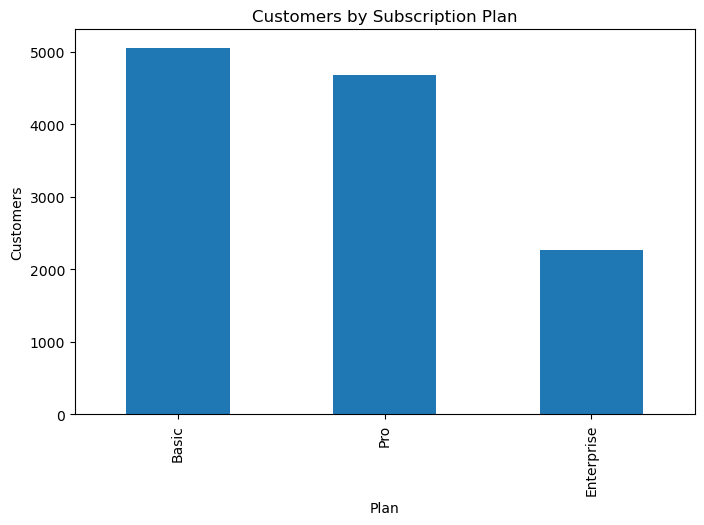

In [108]:
plt.figure(figsize=(8,5))

customer_base["plan_name"].value_counts().plot(
    kind="bar"
)

plt.title("Customers by Subscription Plan")
plt.xlabel("Plan")
plt.ylabel("Customers")

plt.show()

In [109]:
country_counts = (
    customer_base["country"]
    .value_counts()
)

country_counts

country
India        3576
USA          2953
UK           1495
Canada       1204
Australia     978
Germany       932
Singapore     862
Name: count, dtype: int64

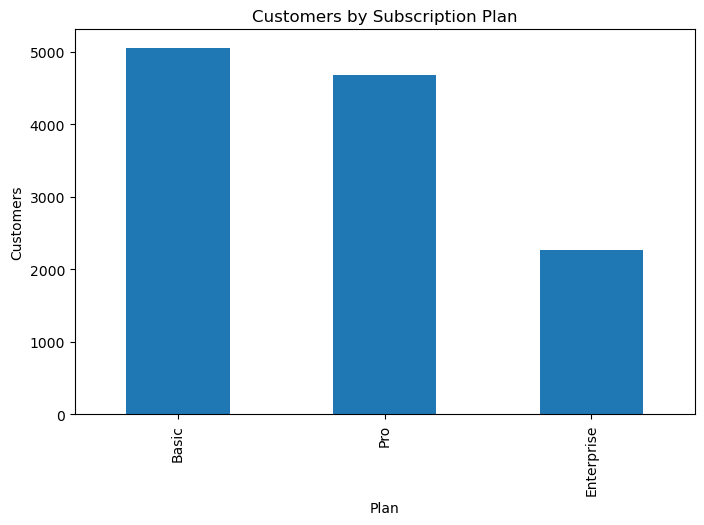

In [110]:
plt.figure(figsize=(8,5))

customer_base["plan_name"].value_counts().plot(
    kind="bar"
)

plt.title("Customers by Subscription Plan")
plt.xlabel("Plan")
plt.ylabel("Customers")

plt.show()

In [111]:
country_counts = (
    customer_base["country"]
    .value_counts()
)

country_counts

country
India        3576
USA          2953
UK           1495
Canada       1204
Australia     978
Germany       932
Singapore     862
Name: count, dtype: int64

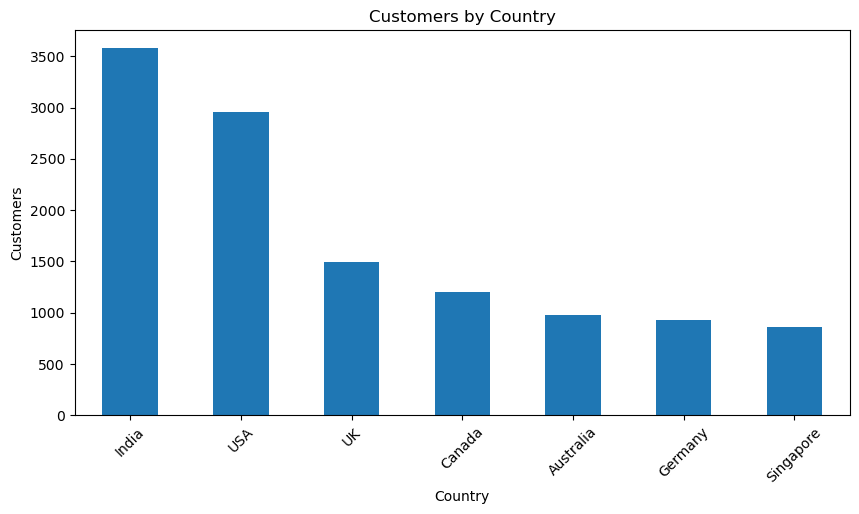

In [112]:
plt.figure(figsize=(10,5))

country_counts.plot(kind="bar")

plt.title("Customers by Country")
plt.xlabel("Country")
plt.ylabel("Customers")

plt.xticks(rotation=45)

plt.show()

In [113]:
industry_counts = (
    customer_base["industry"]
    .value_counts()
)

industry_counts

industry
Education        2049
Technology       2045
Manufacturing    2004
Healthcare       1984
Retail           1966
Finance          1952
Name: count, dtype: int64

In [114]:
acquisition_counts = (
    customer_base["acquisition_channel"]
    .value_counts()
)

acquisition_counts

acquisition_channel
Organic Search    3338
Referral          2652
Paid Ads          2350
Sales             2166
Partner           1494
Name: count, dtype: int64

REVENUE ANALYSIS

In [115]:
active_customers = customer_base[
    customer_base["status"] == "Active"
]

mrr = active_customers["monthly_price"].sum()

print("MRR:", mrr)

MRR: 2038353


In [116]:
arr = mrr * 12

print("ARR:", arr)

ARR: 24460236


In [117]:
active_count = len(active_customers)

arpu = mrr / active_count

print("ARPU:", arpu)

ARPU: 173.5211543372776


In [118]:
revenue_by_plan = (
    active_customers
    .groupby("plan_name")["monthly_price"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_plan

plan_name
Enterprise    1112271
Pro            684953
Basic          241129
Name: monthly_price, dtype: int64

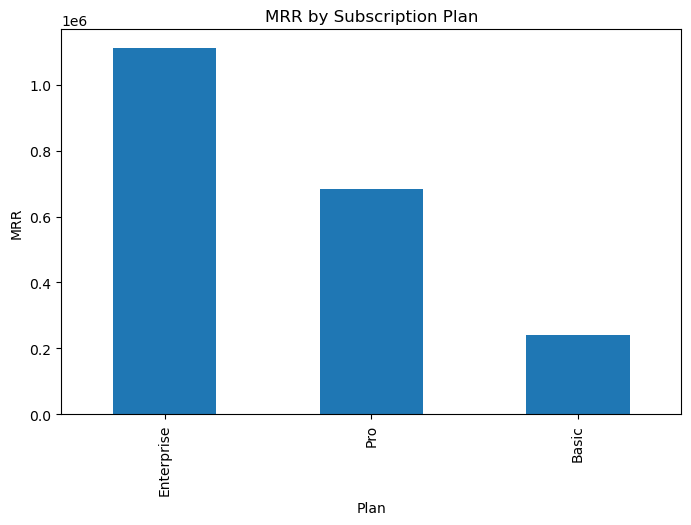

In [119]:
plt.figure(figsize=(8,5))

revenue_by_plan.plot(kind="bar")

plt.title("MRR by Subscription Plan")
plt.xlabel("Plan")
plt.ylabel("MRR")

plt.show()

In [120]:
revenue_by_country = (
    active_customers
    .groupby("country")["monthly_price"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_country

country
India        617693
USA          505659
UK           243041
Canada       203472
Australia    166193
Germany      155242
Singapore    147053
Name: monthly_price, dtype: int64

In [121]:
revenue_by_channel = (
    active_customers
    .groupby("acquisition_channel")
    .agg(
        customers=("customer_id", "nunique"),
        MRR=("monthly_price", "sum")
    )
    .sort_values("MRR", ascending=False)
)

revenue_by_channel

,customers,MRR
acquisition_channel,,
Organic Search,3270,554730
Referral,2584,450816
Paid Ads,2303,406347
Sales,2118,374382
Partner,1472,252078


CHURN ANALYSIS

In [122]:
total_customers = customer_base["customer_id"].nunique()

churned_customers = customer_base[
    customer_base["churn_flag"] == 1
]["customer_id"].nunique()

churn_rate = (
    churned_customers / total_customers
) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", round(churn_rate, 2), "%")

Total Customers: 12000
Churned Customers: 253
Churn Rate: 2.11 %


In [123]:
churn_by_plan = (
    customer_base
    .groupby("plan_name")
    .agg(
        total_customers=("customer_id", "nunique"),
        churned_customers=("churn_flag", "sum")
    )
)

churn_by_plan["churn_rate"] = (
    churn_by_plan["churned_customers"]
    / churn_by_plan["total_customers"]
    * 100
)

churn_by_plan

,total_customers,churned_customers,churn_rate
plan_name,,,
Basic,5055,134,2.650841
Enterprise,2263,34,1.502430
Pro,4682,85,1.815463


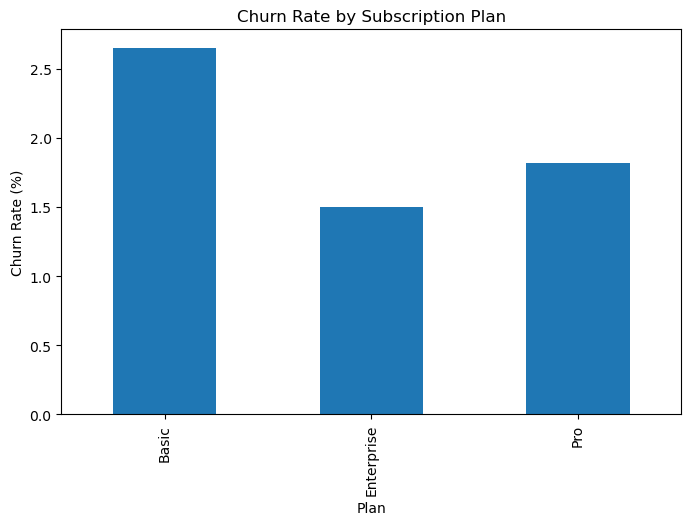

In [124]:
plt.figure(figsize=(8,5))

churn_by_plan["churn_rate"].plot(kind="bar")

plt.title("Churn Rate by Subscription Plan")
plt.xlabel("Plan")
plt.ylabel("Churn Rate (%)")

plt.show()

In [125]:
churn_by_country = (
    customer_base
    .groupby("country")
    .agg(
        customers=("customer_id", "nunique"),
        churned=("churn_flag", "sum")
    )
)

churn_by_country["churn_rate"] = (
    churn_by_country["churned"]
    / churn_by_country["customers"]
    * 100
)

churn_by_country.sort_values(
    "churn_rate",
    ascending=False
)

,customers,churned,churn_rate
country,,,
Germany,932,24,2.575107
UK,1495,36,2.408027
Canada,1204,26,2.159468
Australia,978,21,2.147239
USA,2953,62,2.099560
India,3576,69,1.929530
Singapore,862,15,1.740139


In [126]:
churn_reasons = (
    customer_base[
        customer_base["status"] == "Churned"
    ]["cancellation_reason"]
    .value_counts()
)

churn_reasons

cancellation_reason
Poor Support        52
Missing Features    44
Competitor          42
High Price          41
Business Closure    38
Low Usage           36
Name: count, dtype: int64

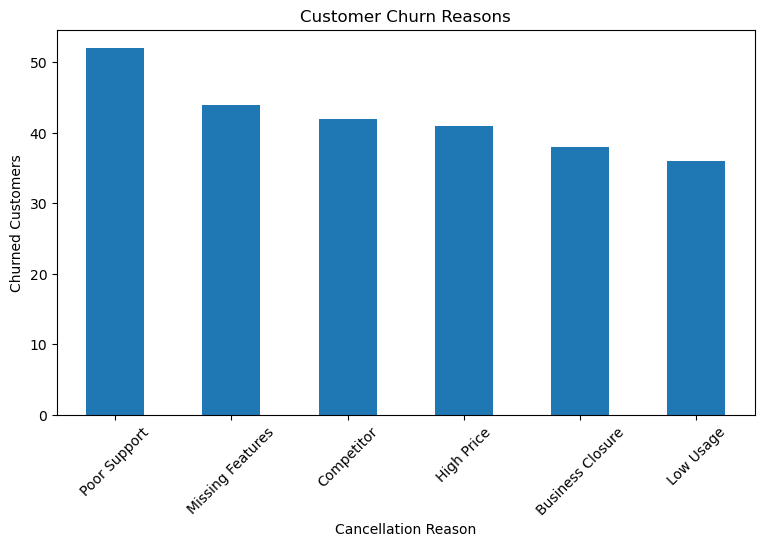

In [127]:
plt.figure(figsize=(9,5))

churn_reasons.plot(kind="bar")

plt.title("Customer Churn Reasons")
plt.xlabel("Cancellation Reason")
plt.ylabel("Churned Customers")

plt.xticks(rotation=45)

plt.show()

USAGE VS CHURN

In [128]:
usage_churn = (
    customer_base
    .groupby("usage_level", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        churned=("churn_flag", "sum")
    )
)

usage_churn["churn_rate"] = (
    usage_churn["churned"]
    / usage_churn["customers"]
    * 100
)

usage_churn

,customers,churned,churn_rate
usage_level,,,
Low Usage,790,3,0.379747
Medium Usage,1921,17,0.884956
High Usage,9289,233,2.508343


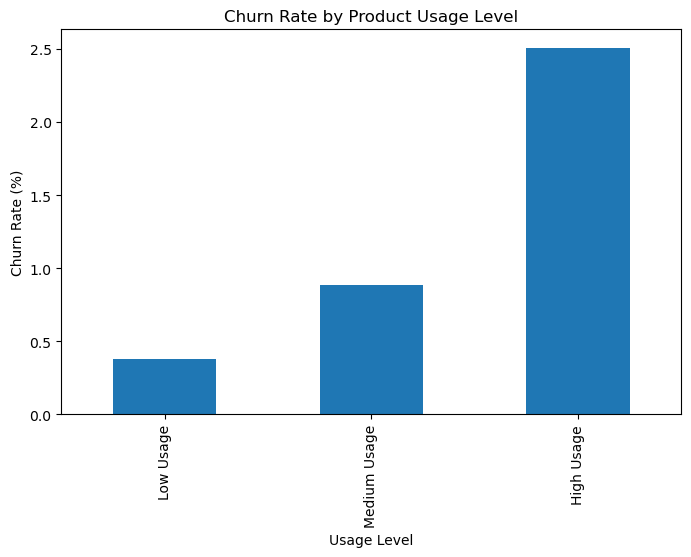

In [129]:
plt.figure(figsize=(8,5))

usage_churn["churn_rate"].plot(kind="bar")

plt.title("Churn Rate by Product Usage Level")
plt.xlabel("Usage Level")
plt.ylabel("Churn Rate (%)")

plt.show()

SUPPORT VS CHURN

In [130]:
print(tickets.columns.tolist())

['ticket_Id', 'customer_id', 'ticket_date', 'issue_type', 'priority', 'resolution_time_hours', 'satisfaction_score', 'ticket_status']


In [131]:
tickets_summary = (
    tickets
    .groupby("customer_id")
    .agg(
        support_ticket_count=("ticket_Id", "count"),
        avg_resolution_time_hours=("resolution_time_hours", "mean"),
        avg_satisfaction_score=("satisfaction_score", "mean")
    )
    .reset_index()
)

In [132]:
tickets_summary.head()

,customer_id,support_ticket_count,avg_resolution_time_hours,avg_satisfaction_score
0,CUST00001,3,25.700000,3.666667
1,CUST00002,3,13.133333,3.000000
2,CUST00003,1,24.800000,3.000000
3,CUST00005,2,22.800000,4.000000
4,CUST00006,3,19.900000,3.666667


In [133]:
customer_base = customer_base.merge(
    tickets_summary,
    on="customer_id",
    how="left"
)

In [134]:
print(customer_base.columns.tolist())

['customer_id', 'signup_date', 'country', 'industry', 'company_size', 'acquisition_channel', 'subscription_id', 'plan_name', 'billing_cycle', 'start_date', 'end_date', 'monthly_price', 'status', 'cancellation_reason', 'upgrade_flag', 'downgrade_flag', 'total_logins_x', 'avg_active_users_x', 'total_sessions_x', 'total_usage_minutes_x', 'total_feature_usage_x', 'total_api_calls_x', 'total_logins_y', 'avg_active_users_y', 'total_sessions_y', 'total_usage_minutes_y', 'total_feature_usage_y', 'total_api_calls_y', 'total_paid_amount', 'failed_payments', 'refunded_amount', 'tenure_months', 'tenure_band', 'total_logins', 'avg_active_users', 'total_sessions', 'total_usage_minutes', 'total_feature_usage', 'total_api_calls', 'usage_level', 'customer_type', 'churn_flag', 'support_ticket_count', 'avg_resolution_time_hours', 'avg_satisfaction_score']


In [135]:
customer_base[
    ["customer_id", "support_ticket_count"]
].head(10)

,customer_id,support_ticket_count
0,CUST00001,3.0
1,CUST00002,3.0
2,CUST00003,1.0
3,CUST00004,NaN
4,CUST00005,2.0
5,CUST00006,3.0
6,CUST00007,2.0
7,CUST00008,1.0
8,CUST00009,2.0
9,CUST00010,3.0


In [136]:
customer_base["support_ticket_count"] = (
    customer_base["support_ticket_count"]
    .fillna(0)
)

In [137]:
customer_base["support_ticket_count"] = (
    customer_base["support_ticket_count"]
    .astype(int)
)

In [138]:
customer_base["support_level"] = pd.cut(
    customer_base["support_ticket_count"],
    bins=[-1, 2, 5, np.inf],
    labels=[
        "Low Support",
        "Medium Support",
        "High Support"
    ]
)

In [139]:
customer_base[
    [
        "customer_id",
        "support_ticket_count",
        "support_level"
    ]
].head(20)

,customer_id,support_ticket_count,support_level
0,CUST00001,3,Medium Support
1,CUST00002,3,Medium Support
2,CUST00003,1,Low Support
3,CUST00004,0,Low Support
4,CUST00005,2,Low Support
5,CUST00006,3,Medium Support
6,CUST00007,2,Low Support
7,CUST00008,1,Low Support
8,CUST00009,2,Low Support
9,CUST00010,3,Medium Support


In [140]:
print(
    customer_base["support_level"].value_counts()
)

support_level
Low Support       7514
Medium Support    4199
High Support       287
Name: count, dtype: int64


In [141]:
customer_base["support_level"] = pd.cut(
    customer_base["support_ticket_count"],
    bins=[-1, 2, 5, np.inf],
    labels=[
        "Low Support",
        "Medium Support",
        "High Support"
    ]
)

In [142]:
customer_base["support_level"] = pd.cut(
    customer_base["support_ticket_count"],
    bins=[-1, 2, 5, np.inf],
    labels=[
        "Low Support",
        "Medium Support",
        "High Support"
    ]
)

In [143]:
customer_base["satisfaction_band"] = pd.cut(
    customer_base["avg_satisfaction_score"],
    bins=[0, 2, 3, 4, 5],
    labels=[
        "Very Low",
        "Low",
        "Good",
        "High"
    ],
    include_lowest=True
)

In [144]:
satisfaction_churn = (
    customer_base
    .groupby("satisfaction_band", observed=True)
    .agg(
        customers=("customer_id", "nunique"),
        churned=("churn_flag", "sum")
    )
)

satisfaction_churn["churn_rate"] = (
    satisfaction_churn["churned"]
    / satisfaction_churn["customers"]
    * 100
)

satisfaction_churn

,customers,churned,churn_rate
satisfaction_band,,,
Very Low,236,2,0.847458
Low,1362,30,2.202643
Good,5455,110,2.016499
High,3580,82,2.290503


CORRELATION ANALYSIS

In [170]:
print(customer_base.columns.tolist())

['customer_id', 'signup_date', 'country', 'industry', 'company_size', 'acquisition_channel', 'subscription_id', 'plan_name', 'billing_cycle', 'start_date', 'end_date', 'monthly_price', 'status', 'cancellation_reason', 'upgrade_flag', 'downgrade_flag', 'total_logins', 'avg_active_users', 'total_sessions', 'total_usage_minutes', 'total_feature_usage', 'total_api_calls', 'support_ticket_count', 'avg_resolution_time_hours', 'avg_satisfaction_score', 'total_paid_amount', 'failed_payments', 'refunded_amount', 'signup_month']


In [171]:
customer_base["churn_flag"] = (
    customer_base["status"]
    .eq("Churned")
    .astype(int)
)

In [172]:
print(
    customer_base[
        ["status", "churn_flag"]
    ].head(10)
)

   status  churn_flag
0  Active           0
1  Active           0
2  Active           0
3  Active           0
4  Active           0
5  Active           0
6  Active           0
7  Active           0
8  Active           0
9  Active           0


In [173]:
print(customer_base["churn_flag"].value_counts())

churn_flag
0    11747
1      253
Name: count, dtype: int64


In [174]:
numeric_features = [
    "monthly_price",
    "total_logins",
    "avg_active_users",
    "total_sessions",
    "total_usage_minutes",
    "total_feature_usage",
    "total_api_calls",
    "support_ticket_count",
    "avg_resolution_time_hours",
    "avg_satisfaction_score",
    "failed_payments",
    "churn_flag"
]

In [175]:
missing_columns = [
    col
    for col in numeric_features
    if col not in customer_base.columns
]

print("Missing columns:")
print(missing_columns)

Missing columns:
[]


In [176]:
for col in numeric_features:
    customer_base[col] = pd.to_numeric(
        customer_base[col],
        errors="coerce"
    )

In [177]:
correlation_matrix = (
    customer_base[numeric_features]
    .corr()
)

In [178]:
correlation_matrix

,monthly_price,total_logins,avg_active_users,total_sessions,total_usage_minutes,total_feature_usage,total_api_calls,support_ticket_count,avg_resolution_time_hours,avg_satisfaction_score,failed_payments,churn_flag
monthly_price,1.000000,0.621763,0.921996,0.620961,0.615252,0.618566,0.611804,-0.003014,0.007684,-0.018214,0.001331,-0.026750
total_logins,0.621763,1.000000,0.626848,0.999841,0.991085,0.993256,0.985982,-0.003306,0.002127,-0.004275,0.275768,0.040413
avg_active_users,0.921996,0.626848,1.000000,0.625780,0.619727,0.623506,0.616760,-0.005741,0.003133,-0.014336,0.002122,-0.029424
total_sessions,0.620961,0.999841,0.625780,1.000000,0.991262,0.993110,0.986103,-0.003469,0.002092,-0.004141,0.276643,0.040528
total_usage_minutes,0.615252,0.991085,0.619727,0.991262,1.000000,0.984342,0.977647,-0.002978,0.003730,-0.004123,0.272325,0.039223
total_feature_usage,0.618566,0.993256,0.623506,0.993110,0.984342,1.000000,0.979187,-0.005317,0.001593,-0.004838,0.272838,0.040082
total_api_calls,0.611804,0.985982,0.616760,0.986103,0.977647,0.979187,1.000000,-0.003281,0.000739,-0.002829,0.274553,0.040003
support_ticket_count,-0.003014,-0.003306,-0.005741,-0.003469,-0.002978,-0.005317,-0.003281,1.000000,0.000863,0.001049,0.008637,-0.009639
avg_resolution_time_hours,0.007684,0.002127,0.003133,0.002092,0.003730,0.001593,0.000739,0.000863,1.000000,0.016156,0.014299,-0.002986
avg_satisfaction_score,-0.018214,-0.004275,-0.014336,-0.004141,-0.004123,-0.004838,-0.002829,0.001049,0.016156,1.000000,-0.002187,0.010839


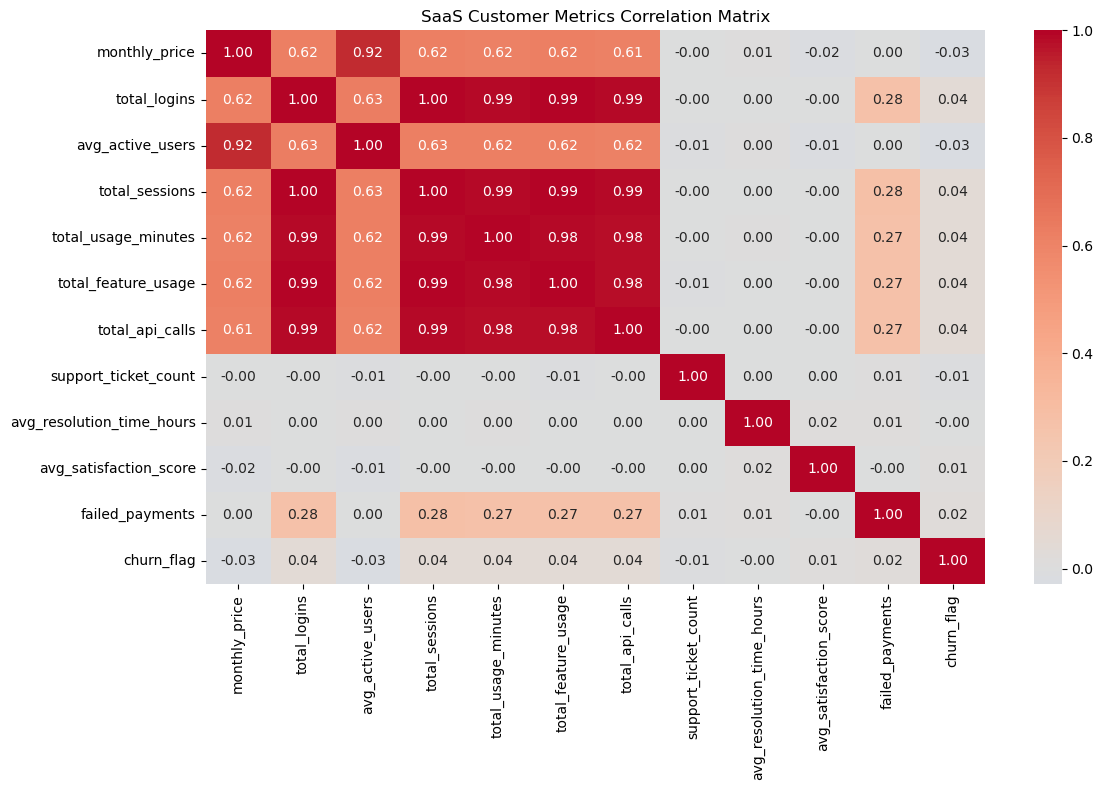

In [179]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("SaaS Customer Metrics Correlation Matrix")
plt.tight_layout()
plt.show()

CUSTOMER SEGMENTATION

In [147]:
mrr_median = customer_base["monthly_price"].median()

usage_median = (
    customer_base["total_usage_minutes"]
    .median()
)

print("MRR Median:", mrr_median)
print("Usage Median:", usage_median)

MRR Median: 149.0
Usage Median: 12625.5


In [150]:
conditions = [
    (
        (customer_base["monthly_price"] >= mrr_median) &
        (customer_base["total_usage_minutes"] >= usage_median)
    ),

    (
        (customer_base["monthly_price"] >= mrr_median) &
        (customer_base["total_usage_minutes"] < usage_median)
    ),

    (
        (customer_base["monthly_price"] < mrr_median) &
        (customer_base["total_usage_minutes"] >= usage_median)
    )
]

choices = [
    "High Value - High Engagement",
    "High Value - Low Engagement",
    "Low Value - High Engagement"
]

customer_base["customer_segment"] = np.select(
    conditions,
    choices,
    default="Low Value - Low Engagement"
)

In [149]:
segment_analysis = (
    customer_base
    .groupby("customer_segment")
    .agg(
        customers=("customer_id", "nunique"),
        total_MRR=("monthly_price", "sum"),
        avg_usage=("total_usage_minutes", "mean"),
        churned=("churn_flag", "sum")
    )
)

segment_analysis["churn_rate"] = (
    segment_analysis["churned"]
    / segment_analysis["customers"]
    * 100
)

segment_analysis

,customers,total_MRR,avg_usage,churned,churn_rate
customer_segment,,,,,
High Value - High Engagement,4821,1363379,28490.227754,108,2.240199
High Value - Low Engagement,2124,463476,6559.425141,11,0.517891
Low Value - High Engagement,1179,57771,15181.318914,55,4.664970
Low Value - Low Engagement,3876,189924,6485.072755,79,2.038184


COHORT ANALYSIS

In [151]:
print("Customers:", customers.shape)
print("Subscription:", subscription.shape)
print("Payment:", payment.shape)
print("metrics:", metrics.shape)
print("tickets:", tickets.shape)

Customers: (12000, 6)
Subscription: (12000, 11)
Payment: (150773, 7)
metrics: (150773, 8)
tickets: (26326, 8)


In [152]:
metrics_summary = (
    metrics
    .groupby("customer_id")
    .agg(
        total_logins=("login_count", "sum"),
        avg_active_users=("active_users", "mean"),
        total_sessions=("sessions", "sum"),
        total_usage_minutes=("usage_minutes", "sum"),
        total_feature_usage=("feature_usage", "sum"),
        total_api_calls=("api_calls", "sum")
    )
    .reset_index()
)

metrics_summary["avg_active_users"] = (
    metrics_summary["avg_active_users"].round(2)
)

In [153]:
print(metrics_summary.head())

  customer_id  total_logins  avg_active_users  total_sessions  \
0   CUST00001           555             10.59            1381   
1   CUST00002           145             13.17             348   
2   CUST00003           176              9.78             457   
3   CUST00004           285              9.14             700   
4   CUST00005           613             19.50            1543   

   total_usage_minutes  total_feature_usage  total_api_calls  
0                30072                  333            95407  
1                 8213                   74            31790  
2                12932                   98            33425  
3                16503                  157            43233  
4                35258                  389            98103  


In [156]:
tickets_summary = (
    tickets
    .groupby("customer_id")
    .agg(
        support_ticket_count=("ticket_Id", "count"),
        avg_resolution_time_hours=("resolution_time_hours", "mean"),
        avg_satisfaction_score=("satisfaction_score", "mean")
    )
    .reset_index()
)

tickets_summary["avg_resolution_time_hours"] = (
    tickets_summary["avg_resolution_time_hours"].round(2)
)

tickets_summary["avg_satisfaction_score"] = (
    tickets_summary["avg_satisfaction_score"].round(2)
)

In [158]:
payment["paid_amount"] = np.where(
    payment["payment_status"] == "Paid",
    payment["amount"],
    0
)

payment["failed_payment_flag"] = np.where(
    payment["payment_status"] == "Failed",
    1,
    0
)

payment["refunded_amount"] = np.where(
    payment["payment_status"] == "Refunded",
    payment["amount"],
    0
)

payment_summary = (
    payment
    .groupby("customer_id")
    .agg(
        total_paid_amount=("paid_amount", "sum"),
        failed_payments=("failed_payment_flag", "sum"),
        refunded_amount=("refunded_amount", "sum")
    )
    .reset_index()
)

In [160]:
customer_base = customers.merge(
    subscription,
    on="customer_id",
    how="left"
)

customer_base = customer_base.merge(
    metrics_summary,
    on="customer_id",
    how="left"
)

customer_base = customer_base.merge(
    tickets_summary,
    on="customer_id",
    how="left"
)

customer_base = customer_base.merge(
    payment_summary,
    on="customer_id",
    how="left"
)

In [161]:
print(customer_base.shape)

(12000, 28)


In [162]:
print(customer_base.columns.tolist())

['customer_id', 'signup_date', 'country', 'industry', 'company_size', 'acquisition_channel', 'subscription_id', 'plan_name', 'billing_cycle', 'start_date', 'end_date', 'monthly_price', 'status', 'cancellation_reason', 'upgrade_flag', 'downgrade_flag', 'total_logins', 'avg_active_users', 'total_sessions', 'total_usage_minutes', 'total_feature_usage', 'total_api_calls', 'support_ticket_count', 'avg_resolution_time_hours', 'avg_satisfaction_score', 'total_paid_amount', 'failed_payments', 'refunded_amount']


In [164]:
date_columns = [
    "signup_date",
    "start_date",
    "end_date"
]

for col in date_columns:
    customer_base[col] = pd.to_datetime(
        customer_base[col],
        errors="coerce"
    )

In [165]:
print(
    customer_base[
        ["signup_date", "start_date", "end_date"]
    ].dtypes
)

signup_date    datetime64[ns]
start_date     datetime64[ns]
end_date       datetime64[ns]
dtype: object


In [166]:
customer_base["signup_month"] = (
    customer_base["signup_date"]
    .dt.to_period("M")
)

In [167]:
customer_base[
    ["customer_id", "signup_date", "signup_month"]
].head(10)

,customer_id,signup_date,signup_month
0,CUST00001,2024-03-06,2024-03
1,CUST00002,2025-07-18,2025-07
2,CUST00003,2025-04-22,2025-04
3,CUST00004,2024-11-16,2024-11
4,CUST00005,2024-11-12,2024-11
5,CUST00006,2025-09-18,2025-09
6,CUST00007,2024-03-03,2024-03
7,CUST00008,2025-05-24,2025-05
8,CUST00009,2024-05-27,2024-05
9,CUST00010,2024-03-09,2024-03


In [182]:
churn_tenure = (
    customer_base[
        customer_base["churn_flag"] == 1
    ]["months_to_churn"]
    .value_counts()
    .sort_index()
)

churn_tenure

months_to_churn
1.0      7
2.0     25
3.0     23
4.0     16
5.0     21
6.0     15
7.0     13
8.0     18
9.0     11
10.0    16
11.0    11
12.0     9
13.0     8
14.0    17
15.0     8
16.0    10
17.0     5
18.0     3
19.0     6
20.0     6
22.0     4
23.0     1
Name: count, dtype: int64

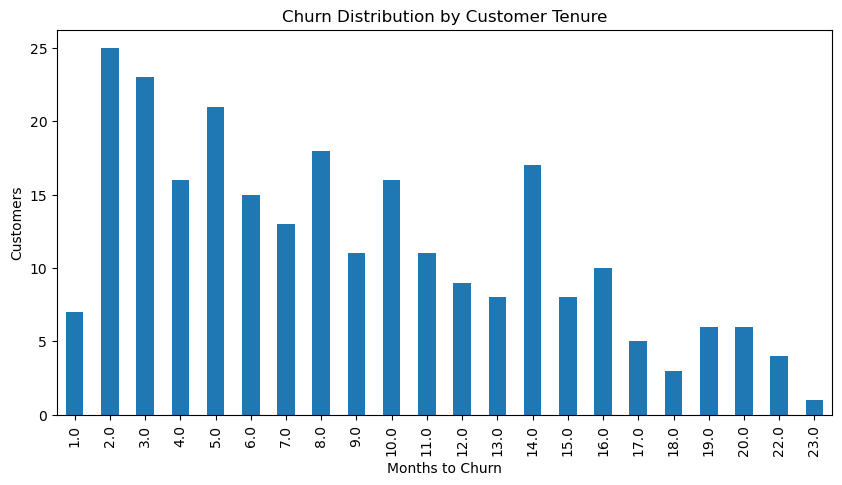

In [183]:
plt.figure(figsize=(10,5))

churn_tenure.plot(kind="bar")

plt.title("Churn Distribution by Customer Tenure")
plt.xlabel("Months to Churn")
plt.ylabel("Customers")

plt.show()

MONTHLY REVENUE

In [185]:
months = pd.date_range(
    start="2024-01-01",
    end="2025-12-01",
    freq="MS"
)

In [187]:
monthly_revenue = []

for month in months:

    month_end = month + pd.offsets.MonthEnd(0)

    active_subscription = subscriptions[
        (subscription["start_date"] <= month_end) &
        (
            subscription["end_date"].isna() |
            (subscription["end_date"] > month_end)
        )
    ]

    mrr = active_subscription["monthly_price"].sum()

    monthly_revenue.append([
        month,
        mrr
    ])

In [188]:
monthly_revenue = pd.DataFrame(
    monthly_revenue,
    columns=["month", "MRR"]
)

In [189]:
monthly_revenue["ARR"] = (
    monthly_revenue["MRR"] * 12
)

MRR growth

In [190]:
monthly_revenue["previous_MRR"] = (
    monthly_revenue["MRR"].shift(1)
)

In [191]:
monthly_revenue["MRR_change"] = (
    monthly_revenue["MRR"]
    - monthly_revenue["previous_MRR"]
)

In [192]:
monthly_revenue["MRR_growth_percent"] = (
    monthly_revenue["MRR_change"]
    / monthly_revenue["previous_MRR"]
    * 100
)

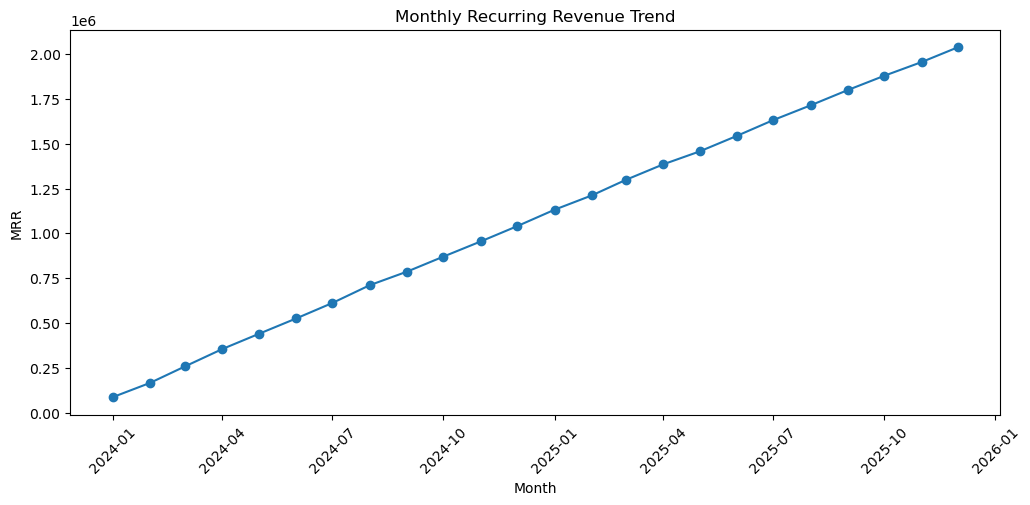

In [193]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["MRR"],
    marker="o"
)

plt.title("Monthly Recurring Revenue Trend")
plt.xlabel("Month")
plt.ylabel("MRR")

plt.xticks(rotation=45)

plt.show()